In [34]:
import os 
import numpy as np
import json
import matplotlib.pyplot as plt
import numpy as np
import netket as nk

In [2]:
with open('outputs/G-equiv_4_hz020.json', 'r') as file:
    data = json.load(file)

In [12]:
data.keys()

dict_keys(['iters', 'energy', 'energy_eom', 'energy_var', 'tau_corr', 'Rsplit', 'Vscore', 'MCMC_accepted', 'MCMC_total', 'equiv_error', 'equiv_error_bulk', 'order_params', 'sim_params'])

In [29]:
iters = data['iters']
energies = data['energy']
energy_var = data['energy_var']

mcmc_accepted = data['MCMC_accepted']
mcmc_total = data['MCMC_total']

In [32]:
energy = [float(energy) for energy in energies]
iters = [float(iter) for iter in iters]
energy_var = [float(e_var) for e_var in energy_var]


mcmc_accepted = np.array([float(accept) for accept in mcmc_accepted])
mcmc_total = np.array([float(tot) for tot in mcmc_total])
# for item in energy:
#     item = float(item)
#     print(item)

In [33]:
axs

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

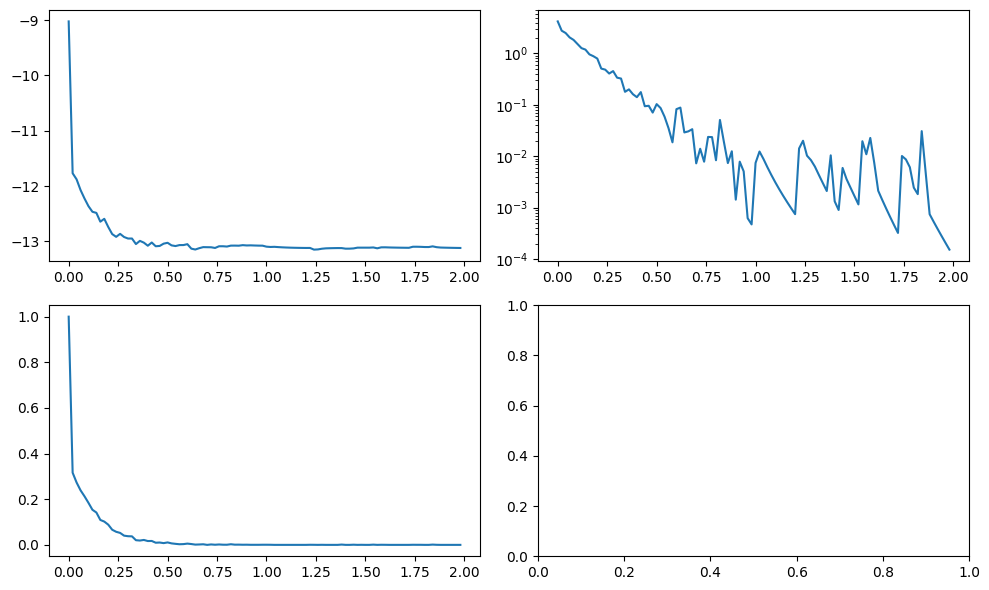

In [34]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

axs[0, 0].plot(iters, energy)

axs[0, 1].plot(iters, energy_var)
axs[0, 1].set_yscale('log') 

axs[1, 0].plot(iters, mcmc_accepted/mcmc_total)

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import netket as nk
from typing import List, Tuple, Dict, Any, Optional, Union

Lx = 3
Ly = 3

def map1Dto2D(n: int) -> Tuple[int, int]:
    """Map a 1D index to 2D coordinates."""
    return int(np.floor(n / Ly)), n % Ly

Lx = 3
Ly = 3
basis = [np.array([1, 0]), np.array([0, 1])]
lattice_coord = [map1Dto2D(j)[0] * basis[0] + map1Dto2D(j)[1] * basis[1]  for j in range(0, Lx * Ly)]


In [12]:
lattice_coord

[array([0, 0]),
 array([0, 1]),
 array([0, 2]),
 array([1, 0]),
 array([1, 1]),
 array([1, 2]),
 array([2, 0]),
 array([2, 1]),
 array([2, 2])]

In [ ]:
def _map1Dto2D(n: int) -> Tuple[int, int]:
        """Map a 1D index to 2D coordinates."""
        return int(np.floor(n / self.Ly)), n % self.Ly

In [ ]:
# Generate lattice coordinates
lattice_coord = [self._map1Dto2D(j)[0] * basis[0] + 
                self._map1Dto2D(j)[1] * basis[1] 
                         for j in range(0, self.Lx * self.Ly)]

In [66]:
Lx = 2 
Ly = 2 
Lz = 2
def map1Dto3D(n: int):
    """Map a 1D index to 3D coordinates as in (x, y, z)."""
    quotient, remainder = divmod(n, (Ly * Lx))
    return (remainder // Ly, remainder % Ly , quotient)

In [67]:
# Lattice basis
basis = [np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1])]

# Atom basis for toric code
basis_atoms = [[1/2, 0, 0], [0, 1/2, 0], [0, 0, 1/2]]

# Generate lattice coordinates
lattice_coord = [map1Dto3D(j)[0] * basis[0] + 
                map1Dto3D(j)[1] * basis[1] +
                map1Dto3D(j)[2] * basis[2]
                for j in range(0, Lx * Ly * Lz)]

# Generate qubit coordinates (they're at half-offsets between edges)
atom_coord = []
for j in range(0, len(basis_atoms)):
    atom_coord += (lattice_coord + np.array(basis_atoms[j])).tolist()
atom_coord = np.array(atom_coord)

# Sort atomic coordinates
atom_coord = atom_coord[np.lexsort((atom_coord[:, 0], atom_coord[:, 1], atom_coord[:, 2]))]

In [68]:
atom_coord

array([[0.5, 0. , 0. ],
       [1.5, 0. , 0. ],
       [0. , 0.5, 0. ],
       [1. , 0.5, 0. ],
       [0.5, 1. , 0. ],
       [1.5, 1. , 0. ],
       [0. , 1.5, 0. ],
       [1. , 1.5, 0. ],
       [0. , 0. , 0.5],
       [1. , 0. , 0.5],
       [0. , 1. , 0.5],
       [1. , 1. , 0.5],
       [0.5, 0. , 1. ],
       [1.5, 0. , 1. ],
       [0. , 0.5, 1. ],
       [1. , 0.5, 1. ],
       [0.5, 1. , 1. ],
       [1.5, 1. , 1. ],
       [0. , 1.5, 1. ],
       [1. , 1.5, 1. ],
       [0. , 0. , 1.5],
       [1. , 0. , 1.5],
       [0. , 1. , 1.5],
       [1. , 1. , 1.5]])

In [75]:
dg_v = nk.graph.Lattice(basis_vectors=basis, pbc=True, extent=[Lx, Ly, Lz])
dg_p = nk.graph.Lattice(basis_vectors=basis, pbc=True, site_offsets=[[1/2, 1/2, 0],[0, 1/2, 1/2],[1/2, 0, 1/2]], extent=[Lx, Ly, Lz])

In [76]:
dg_v.positions

array([[0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 1.],
       [1., 0., 0.],
       [1., 0., 1.],
       [1., 1., 0.],
       [1., 1., 1.]])

In [84]:
dg_p.positions

array([[0.5, 0.5, 0. ],
       [0. , 0.5, 0.5],
       [0.5, 0. , 0.5],
       [0.5, 0.5, 1. ],
       [0. , 0.5, 1.5],
       [0.5, 0. , 1.5],
       [0.5, 1.5, 0. ],
       [0. , 1.5, 0.5],
       [0.5, 1. , 0.5],
       [0.5, 1.5, 1. ],
       [0. , 1.5, 1.5],
       [0.5, 1. , 1.5],
       [1.5, 0.5, 0. ],
       [1. , 0.5, 0.5],
       [1.5, 0. , 0.5],
       [1.5, 0.5, 1. ],
       [1. , 0.5, 1.5],
       [1.5, 0. , 1.5],
       [1.5, 1.5, 0. ],
       [1. , 1.5, 0.5],
       [1.5, 1. , 0.5],
       [1.5, 1.5, 1. ],
       [1. , 1.5, 1.5],
       [1.5, 1. , 1.5]])

In [86]:
np.unique(dg_p.positions)

array([0. , 0.5, 1. , 1.5])

In [88]:
from Three_TC.model.geometry import ThreeD_ToricCodeGeometry

In [90]:
test = ThreeD_ToricCodeGeometry(Lx=2, Ly=2, Lz=2, bc='PBC')

In [24]:
# import _path  # noqa: F401   <-- ADD THIS FIRST
import numpy as np
import netket as nk
import jax.numpy as jnp
from jax import random
from tqdm import tqdm
from simulation.custom_sampler import WeightedRule, MultiRule

from Three_TC.model.geometry import ThreeD_ToricCodeGeometry
from Three_TC.model.hamiltonian import create_hamiltonian

In [53]:
geo = ThreeD_ToricCodeGeometry(Lx=2, Ly=2, Lz=2, bc='PBC')
hi = nk.hilbert.Spin(s=1/2, N=geo.N)
Ham = create_hamiltonian(
    hi=hi, vertex_all=geo.vertex_all, plaq_all=geo.plaq_all, 
    bonds=geo.bonds
)

In [54]:
Ham

PauliStrings(hilbert=Spin(s=1/2, N=24, ordering=new), n_strings=32, dtype=complex128, dict(operators:weights)=
    XXXIIIXIXIIIIIIIIIIIXIII : (-1+0j),
    IIIIIIIIXIIIXXXIIIXIXIII : (-1+0j),
    IIXIXXXIIIXIIIIIIIIIIIXI : (-1+0j),
    IIIIIIIIIIXIIIXIXXXIIIXI : (-1+0j),
    XXIXIIIXIXIIIIIIIIIIIXII : (-1+0j),
    IIIIIIIIIXIIXXIXIIIXIXII : (-1+0j),
    IIIXXXIXIIIXIIIIIIIIIIIX : (-1+0j),
    IIIIIIIIIIIXIIIXXXIXIIIX : (-1+0j),
    IIZIIIIIZIZIIIZIIIIIIIII : (-1+0j),
    IIZIIIIIIIIIIIZIIIIIZIZI : (-1+0j),
    IIIIIIZIZIZIIIIIIIZIIIII : (-1+0j),
    IIIIIIZIIIIIIIIIIIZIZIZI : (-1+0j),
    IIIZIIIIIZIZIIIZIIIIIIII : (-1+0j),
    IIIZIIIIIIIIIIIZIIIIIZIZ : (-1+0j),
    IIIIIIIZIZIZIIIIIIIZIIII : (-1+0j),
    IIIIIIIZIIIIIIIIIIIZIZIZ : (-1+0j),
    ZIIIIIIIZZIIZIIIIIIIIIII : (-1+0j),
    ZIIIIIIIIIIIZIIIIIIIZZII : (-1+0j),
    IIIIZIIIIIZZIIIIZIIIIIII : (-1+0j),
    IIIIZIIIIIIIIIIIZIIIIIZZ : (-1+0j),
    IZIIIIIIZZIIIZIIIIIIIIII : (-1+0j),
    IZIIIIIIIIIIIZIIIIIIZZII : (-1+0j),
    IIIII

In [55]:
key = random.PRNGKey(42)
plaq_idx = jnp.asarray(geo.plaq_all)
random_array = random.bernoulli(key=key,p=0.5, shape=(3,24)).astype(jnp.int32)

In [56]:
plaq_idx

Array([[10,  8, 14,  2],
       [22, 20,  2, 14],
       [ 8, 10, 18,  6],
       [20, 22,  6, 18],
       [11,  9, 15,  3],
       [23, 21,  3, 15],
       [ 9, 11, 19,  7],
       [21, 23,  7, 19],
       [ 9,  8, 12,  0],
       [21, 20,  0, 12],
       [11, 10, 16,  4],
       [23, 22,  4, 16],
       [ 8,  9, 13,  1],
       [20, 21,  1, 13],
       [10, 11, 17,  5],
       [22, 23,  5, 17],
       [ 3,  2,  4,  0],
       [15, 14, 16, 12],
       [ 7,  6,  0,  4],
       [19, 18, 12, 16],
       [ 2,  3,  5,  1],
       [14, 15, 17, 13],
       [ 6,  7,  1,  5],
       [18, 19, 13, 17]], dtype=int64)

In [57]:
random_array 

Array([[1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
        0, 0],
       [1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
        1, 0],
       [1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        1, 1]], dtype=int32)

In [58]:
# In test_tiny_MLP.py or a quick notebook
N_plaq = len(geo.plaq_all)
print(f"N_plaq = {N_plaq} = 3 * L³ = {3 * geo.Lx**3}")
# Reshape works iff orientations are in blocks of L³ and the inner loops are (ix, iy, iz)

N_plaq = 24 = 3 * L³ = 24


In [60]:
geo.plaq_all[0]

[10, 8, 14, 2]

In [61]:
geo.plaq_all[8]

[9, 8, 12, 0]